# Prophet Modelling

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import dask.dataframe as dd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Define data types for columns to optimize memory usage
dtype = {
    'latitude': 'float32',
    'longitude': 'float32',
    'pm2p5': 'float32',
    'pm10': 'float32',
    'u10': 'float32',
    'v10': 'float32',
    't2m': 'float32',
    'bcaod550': 'float32',
    'duaod550': 'float32',
    'lsm': 'float32',
    'sp': 'float32'
}

csv_path = "/home/julia/smoglens/data/data_sfc.csv"
ddf = dd.read_csv(csv_path, parse_dates=['valid_time'], dtype=dtype).compute()

ddf['timestamp'] = pd.to_datetime(ddf['valid_time'], utc=True)
ddf.drop(columns=['valid_time'], inplace=True)
ddf.rename(columns={'latitude': 'lat', 'longitude': 'lon', 'pm2p5': 'pm25', 'pm10': 'pm10'}, inplace=True)

print(ddf.head())
print(ddf.info())

    lat    lon       u10       v10         t2m  bcaod550  duaod550       lsm  \
0  49.5  70.00  2.817483  3.943344  266.944611  0.000206  0.000011  0.989188   
1  49.5  70.75  2.887795  5.084457  266.280548  0.000199  0.000010  0.995354   
2  49.5  71.50  2.983499  5.849106  265.509064  0.000203  0.000010  0.994766   
3  49.5  72.25  3.118264  6.141586  264.616486  0.000223  0.000009  0.992191   
4  49.5  73.00  3.338479  5.872055  263.298126  0.000263  0.000009  0.990747   

           pm25          pm10         sp                 timestamp  
0  7.730705e-12  1.159606e-11  97576.125 2023-01-01 00:00:00+00:00  
1  7.275958e-12  1.068656e-11  97371.125 2023-01-01 00:00:00+00:00  
2  3.296918e-12  4.774847e-12  97140.125 2023-01-01 00:00:00+00:00  
3  3.240075e-11  4.604317e-11  96743.125 2023-01-01 00:00:00+00:00  
4  8.753887e-11  1.242597e-10  95869.125 2023-01-01 00:00:00+00:00  
<class 'pandas.core.frame.DataFrame'>
Index: 29409592 entries, 0 to 487585
Data columns (total 12 columns

In [4]:
ddf_prophet = ddf[['timestamp', 'pm25']].copy()
ddf_prophet.columns = ['timestamp', 'pm25']
ddf_prophet['timestamp'] = pd.to_datetime(ddf_prophet['timestamp'])

ddf_prophet.head()

,timestamp,pm25
0,2023-01-01 00:00:00+00:00,7.730705e-12
1,2023-01-01 00:00:00+00:00,7.275958e-12
2,2023-01-01 00:00:00+00:00,3.296918e-12
3,2023-01-01 00:00:00+00:00,3.240075e-11
4,2023-01-01 00:00:00+00:00,8.753887e-11


## Plotting the Data



In [ ]:
print(ddf_prophet.info())
print(ddf_prophet.isnull().sum())
print(ddf_prophet.shape)


<class 'pandas.core.frame.DataFrame'>
Index: 29409592 entries, 0 to 487585
Data columns (total 2 columns):
 #   Column     Dtype              
---  ------     -----              
 0   timestamp  datetime64[ns, UTC]
 1   pm25       float32            
dtypes: datetime64[ns, UTC](1), float32(1)
memory usage: 560.9 MB
None
timestamp    0
pm25         0
dtype: int64
(29409592, 2)


In [12]:
ddf_hourly = (
    ddf_prophet
    .resample('H', on='timestamp')
    .mean()
    .fillna(method='ffill')  # forward fill
    .reset_index()
)

ddf_hourly.rename(columns={'timestamp': 'ds', 'pm25': 'y'}, inplace=True)
print(ddf_hourly.head())


/tmp/ipykernel_343637/1900897401.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ddf_prophet


                         ds             y
0 2023-01-01 00:00:00+00:00  4.657917e-08
1 2023-01-01 01:00:00+00:00  4.657917e-08
2 2023-01-01 02:00:00+00:00  4.657917e-08
3 2023-01-01 03:00:00+00:00  3.980552e-08
4 2023-01-01 04:00:00+00:00  3.980552e-08


/tmp/ipykernel_343637/1900897401.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ddf_prophet


aggregated it hourly and because of NaNs filled the missing data for consistency

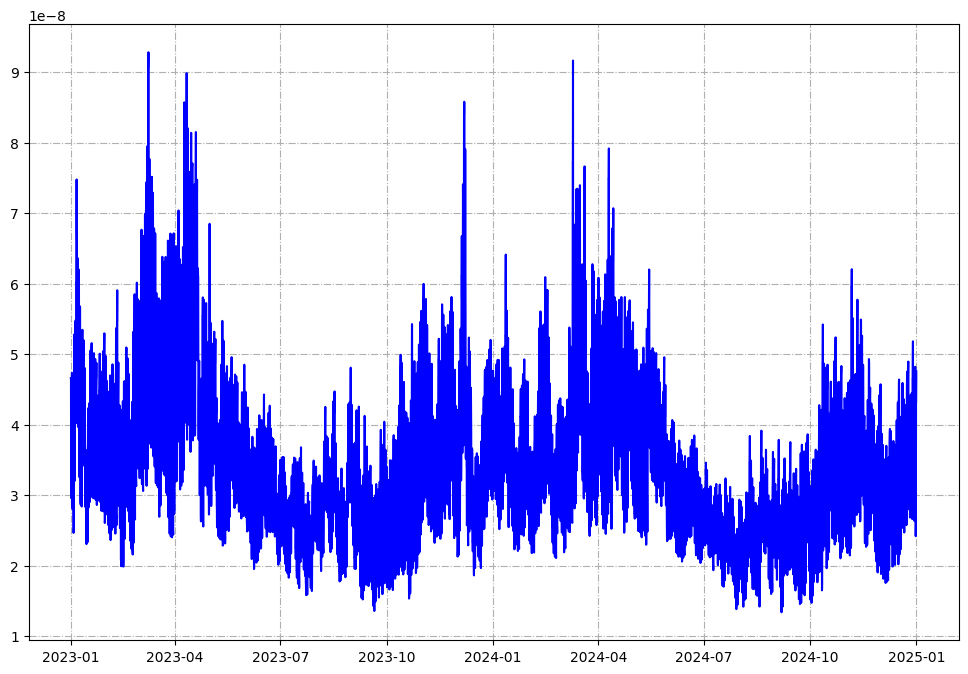

In [13]:
plt.figure(figsize=(12, 8))
plt.grid(linestyle='-.')

plt.plot(ddf_hourly['ds'], ddf_hourly['y'], 'b')
plt.show()

## Fitting the Data

In [18]:
split_idx = int(len(ddf_hourly) * 0.8)  # 80% train
train = ddf_hourly.iloc[:split_idx]
test = ddf_hourly.iloc[split_idx:]

print(train.shape, test.shape)


(14033, 2) (3509, 2)


In [19]:
train

,ds,y
0,2023-01-01 00:00:00+00:00,0.046579
1,2023-01-01 01:00:00+00:00,0.046579
2,2023-01-01 02:00:00+00:00,0.046579
3,2023-01-01 03:00:00+00:00,0.039806
4,2023-01-01 04:00:00+00:00,0.039806
...,...,...
14028,2024-08-07 12:00:00+00:00,0.021622
14029,2024-08-07 13:00:00+00:00,0.021622
14030,2024-08-07 14:00:00+00:00,0.021622
14031,2024-08-07 15:00:00+00:00,0.027466


In [21]:
# Remove timezone from 'ds' column before fitting
train_no_tz = train.copy()
train_no_tz['ds'] = train_no_tz['ds'].dt.tz_localize(None)

model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)
model.fit(train_no_tz)

21:58:52 - cmdstanpy - INFO - Chain [1] start processing
21:58:56 - cmdstanpy - INFO - Chain [1] done processing


## Make Future Predictions

In [23]:
# Forecast 36 hours ahead
horizon = 36
future = model.make_future_dataframe(periods=horizon, freq='H')
forecast = model.predict(future)

# View last few predictions
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

/home/julia/.pyenv/versions/smoglens/lib/python3.10/site-packages/prophet/forecaster.py:1872: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
14064,2024-08-09 00:00:00,0.032673,0.024835,0.040870
14065,2024-08-09 01:00:00,0.030795,0.023226,0.038796
14066,2024-08-09 02:00:00,0.028162,0.020167,0.035991
14067,2024-08-09 03:00:00,0.025094,0.016598,0.033256
14068,2024-08-09 04:00:00,0.021963,0.014284,0.028969


## Plotting the Forecast

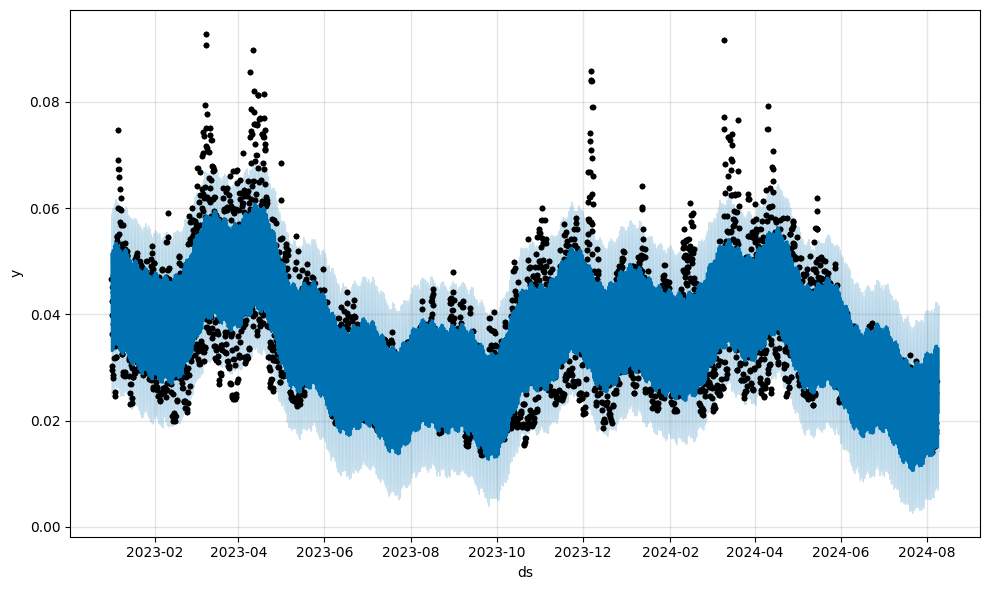

In [24]:
ax = model.plot(forecast);

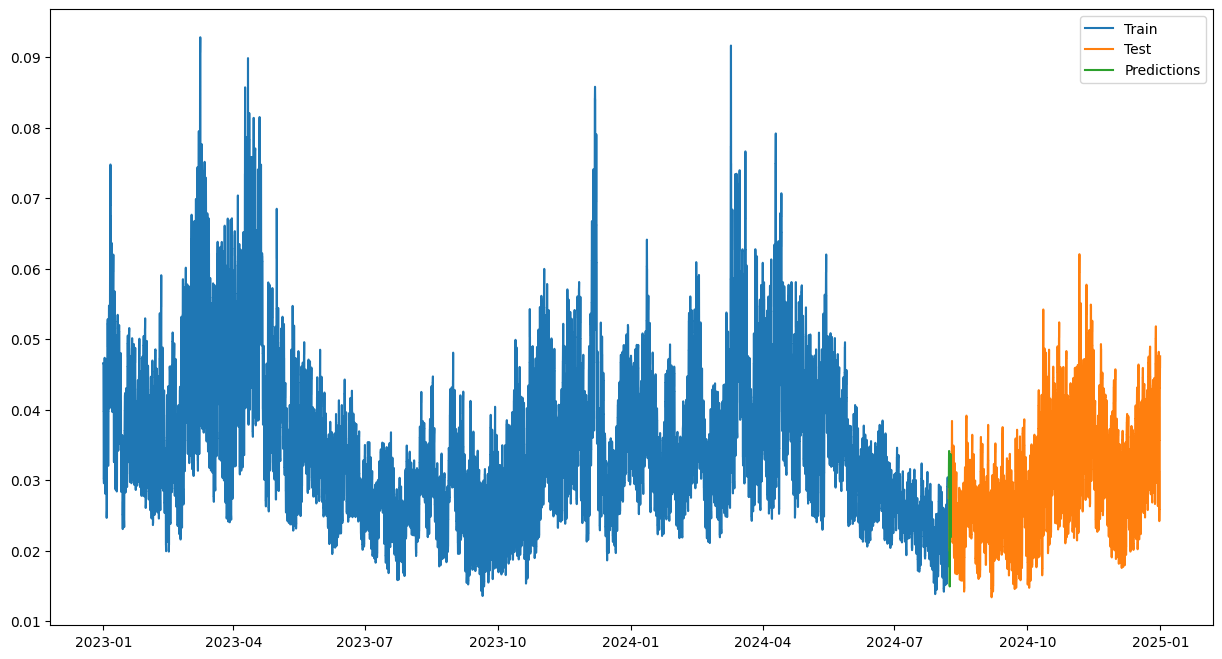

In [25]:
plt.figure(figsize=(15, 8))
plt.plot(train['ds'], train['y'], label="Train")
plt.plot(test['ds'], test['y'], label="Test")
plt.plot(forecast['ds'].iloc[-horizon:], forecast['yhat'].iloc[-horizon:], label="Predictions")
plt.legend(loc="best")
plt.show()

## Time Series' Trend and Seasonality

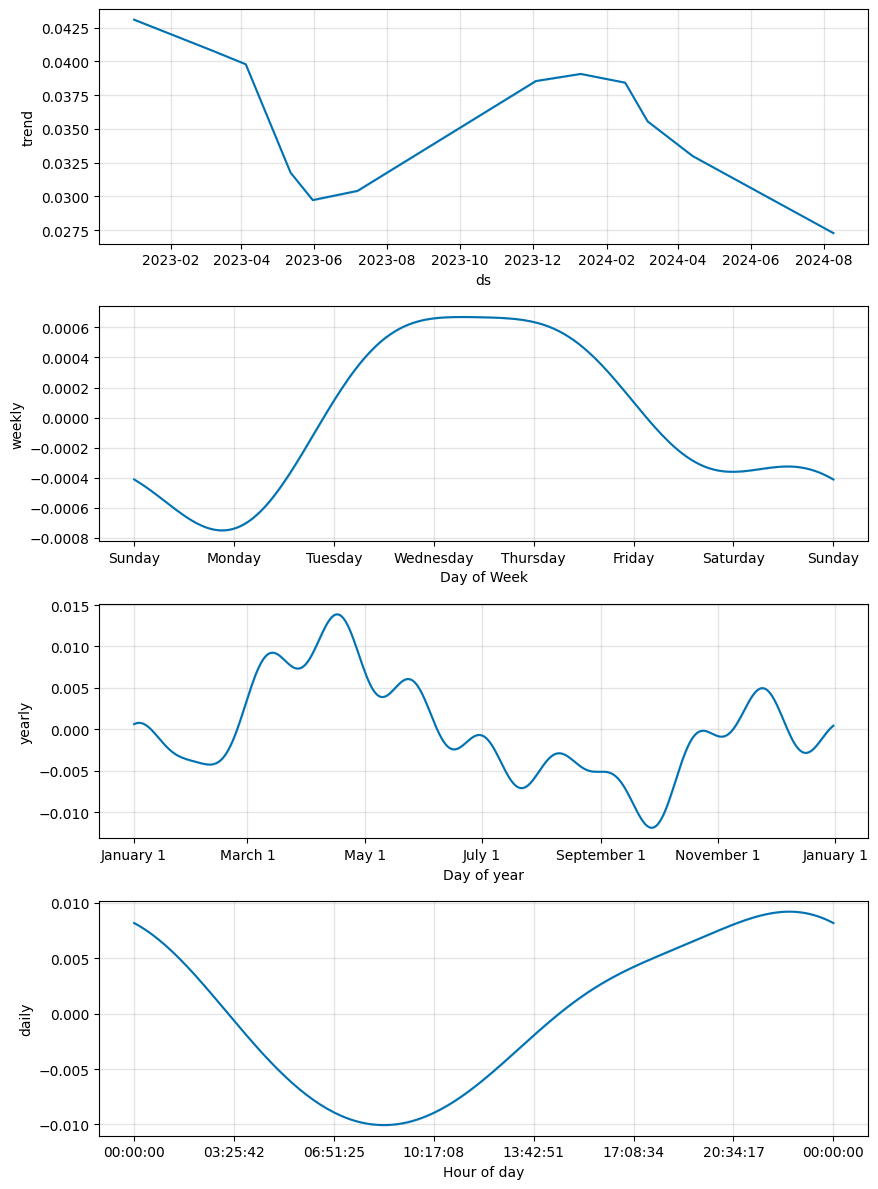

In [26]:
model.plot_components(forecast);

## Evaluating the Model with Cross-Validation

In [31]:
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import r2_score

cv_results = cross_validation(
    model=model,
    initial='365 days',   # 1-year training
    horizon='182 days',   # 6-month validation
    period='90 days'      # shift each fold 3 months
)

# Compute metrics
df_metrics = performance_metrics(cv_results)
print(df_metrics[['horizon', 'mae', 'rmse', 'mape']])

# R² for validation predictions
y_true = cv_results['y'].values
y_pred = cv_results['yhat'].values
r2 = r2_score(y_true, y_pred)
print("R²:", r2)


Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/1 [00:00<?, ?it/s]

22:22:43 - cmdstanpy - INFO - Chain [1] start processing
22:22:44 - cmdstanpy - INFO - Chain [1] done processing


               horizon       mae      rmse      mape
0     18 days 04:00:00  0.008904  0.010089  0.232665
1     18 days 05:00:00  0.008922  0.010098  0.233102
2     18 days 06:00:00  0.008940  0.010108  0.233547
3     18 days 07:00:00  0.008960  0.010118  0.234057
4     18 days 08:00:00  0.008972  0.010122  0.234332
...                ...       ...       ...       ...
3928 181 days 20:00:00  0.004448  0.005421  0.205715
3929 181 days 21:00:00  0.004423  0.005383  0.204628
3930 181 days 22:00:00  0.004405  0.005354  0.203883
3931 181 days 23:00:00  0.004383  0.005327  0.202874
3932 182 days 00:00:00  0.004364  0.005301  0.202107

[3933 rows x 4 columns]
R²: 0.5900249571513069


/home/julia/.pyenv/versions/smoglens/lib/python3.10/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/home/julia/.pyenv/versions/smoglens/lib/python3.10/site-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


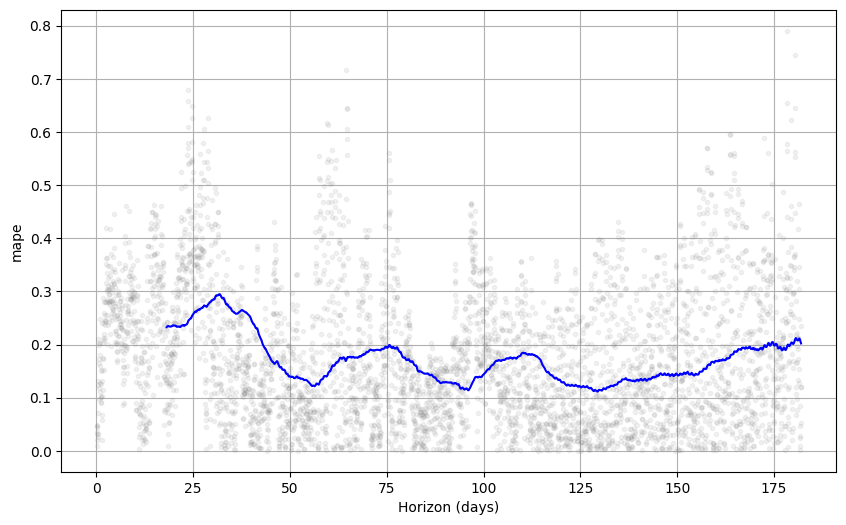

In [32]:
plot_cross_validation_metric(cv_results, metric='mape');